In [1]:
import sys
import types
m = types.ModuleType('pyjks')
sys.modules['pyjks'] = m

import os
from dotenv import load_dotenv
import hopsworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()
API_KEY_HS = os.getenv('API_KEY_HS')

project = hopsworks.login(
    api_key_value=API_KEY_HS,
    project="Pearls_AQI_Predictor12",
    host="eu-west.cloud.hopsworks.ai"
)
fs = project.get_feature_store()
fg = fs.get_feature_group("weather_pollution_features", version=1)

df = fg.read()
print(f"✅ Loaded {len(df)} rows")
df.head()

2026-05-19 19:09:26,677 WARNING: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'

2026-05-19 19:09:26,690 WARNING: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

2026-05-19 19:09:26,693 WARNING: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'

2026-05-19 19:09:27,577 WARNING: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'

2026-05-19 19:09:27,945 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'parseString' deprecated - use 'parse_string'
2026-05-19 19:09:27,945 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'
2026-05-19 19:09:30,382 INFO: Initiali

2026-05-19 19:09:34,828 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/31959
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (3.71s) 
✅ Loaded 4114 rows


,temperature,feels_like,temp_min,temp_max,humidity,pressure,sea_level,grnd_level,wind_speed,wind_direction,...,pm25_exceeds_who,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,1,4,341.77,0,0.96,171.97,5.62,66.35,129.68,4
1,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,1,4,137.61,0,0.32,81.58,0.36,54.78,143.81,0
2,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,1,4,138.27,0,0.15,99.37,0.64,38.73,109.88,0
3,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,1,3,258.86,0,2.75,89.15,8.73,32.11,60.94,1
4,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,1,3,156.67,0,0.10,90.31,0.36,32.74,91.70,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['event_timestamp'].min(), "→", df['event_timestamp'].max())

Shape: (4114, 30)

Columns: ['temperature', 'feels_like', 'temp_min', 'temp_max', 'humidity', 'pressure', 'sea_level', 'grnd_level', 'wind_speed', 'wind_direction', 'wind_gust', 'clouds', 'weather_main', 'weather_description', 'rain_1h', 'snow_1h', 'location', 'event_timestamp', 'timestamp', 'aqi_is_poor', 'pm25_exceeds_who', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

Missing values:
 temperature            0
feels_like             0
temp_min               0
temp_max               0
humidity               0
pressure               0
sea_level              0
grnd_level             0
wind_speed             0
wind_direction         0
wind_gust              9
clouds                 0
weather_main           0
weather_description    0
rain_1h                0
snow_1h                0
location               0
event_timestamp        0
timestamp              0
aqi_is_poor            0
pm25_exceeds_who       0
aqi                    0
co                     0
no              

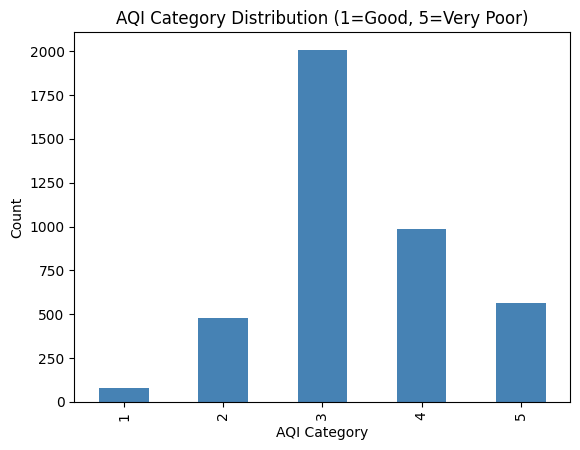

In [3]:
df['aqi'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('AQI Category Distribution (1=Good, 5=Very Poor)')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.show()

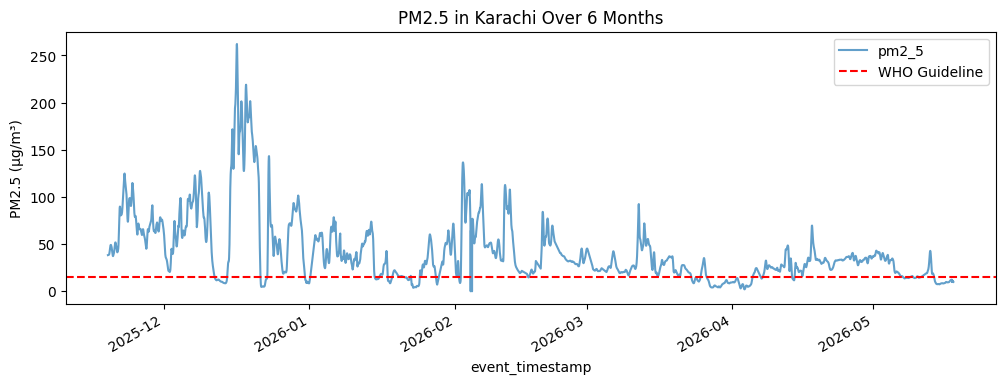

In [ ]:
df.set_index('event_timestamp')['pm2_5'].plot(figsize=(12,4), alpha=0.7)
plt.title(f'PM2.5 in Karachi ({df["event_timestamp"].min().strftime("%b %Y")} → {df["event_timestamp"].max().strftime("%b %Y")})')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=15, color='red', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

In [4]:
# Ensure datetime
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

# Add time features
df['hour_of_day'] = df['event_timestamp'].dt.hour
df['day_of_week'] = df['event_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("✅ Added: hour_of_day, day_of_week, is_weekend")

✅ Added: hour_of_day, day_of_week, is_weekend


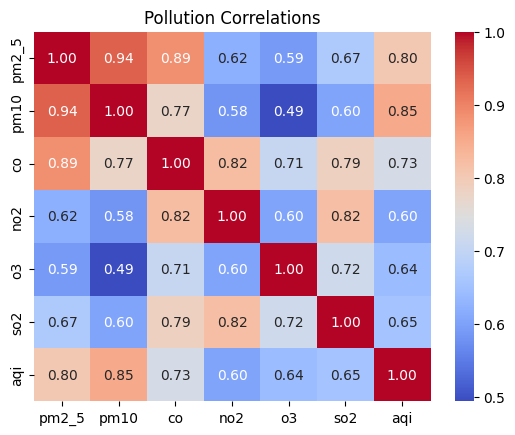

In [5]:
pollution_cols = ['pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'aqi']
sns.heatmap(df[pollution_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pollution Correlations')
plt.show()

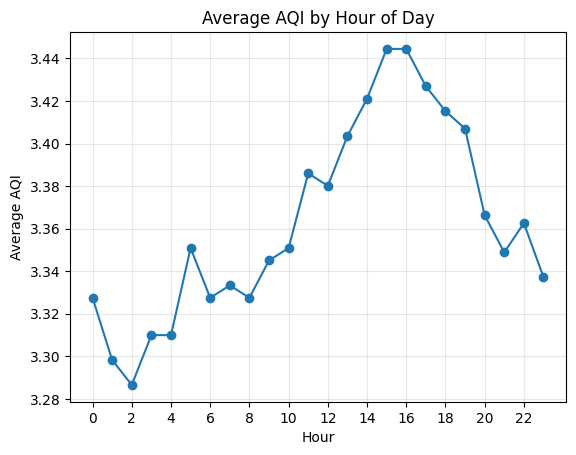

In [8]:
df.groupby('hour_of_day')['aqi'].mean().plot(marker='o')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
print("AQI Distribution:")
print(df['aqi'].value_counts().sort_index())
print("\nPercentage:")
print((df['aqi'].value_counts(normalize=True).sort_index() * 100).round(1))

AQI Distribution:
aqi
1      78
2     476
3    2008
4     987
5     565
Name: count, dtype: int64

Percentage:
aqi
1     1.9
2    11.6
3    48.8
4    24.0
5    13.7
Name: proportion, dtype: float64


In [7]:
poor_pct = df['aqi_is_poor'].mean() * 100
print(f"Karachi has POOR air quality {poor_pct:.1f}% of the time")
print(f"PM2.5 exceeds WHO guidelines {(df['pm25_exceeds_who'].mean() * 100):.1f}% of the time")

Karachi has POOR air quality 86.5% of the time
PM2.5 exceeds WHO guidelines 81.5% of the time


In [8]:
hourly_aqi = df.groupby('hour_of_day')['aqi'].mean()
print("Best hours (lowest AQI):")
print(hourly_aqi.nsmallest(3))
print("\nWorst hours (highest AQI):")
print(hourly_aqi.nlargest(3))

Best hours (lowest AQI):
hour_of_day
2    3.284884
1    3.298246
3    3.304094
Name: aqi, dtype: float64

Worst hours (highest AQI):
hour_of_day
16    3.444444
15    3.441860
14    3.418605
Name: aqi, dtype: float64


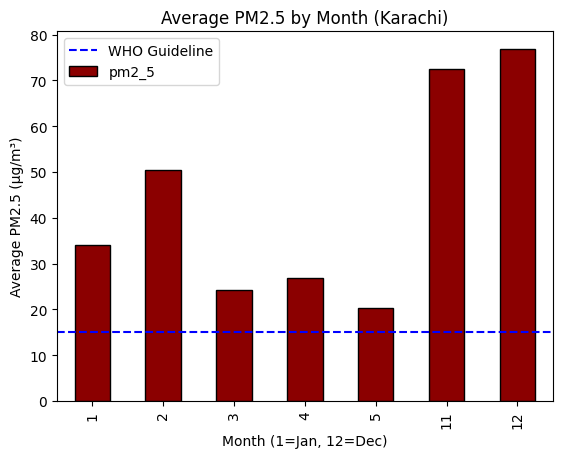

In [9]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm2_5'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM2.5 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.axhline(y=15, color='blue', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

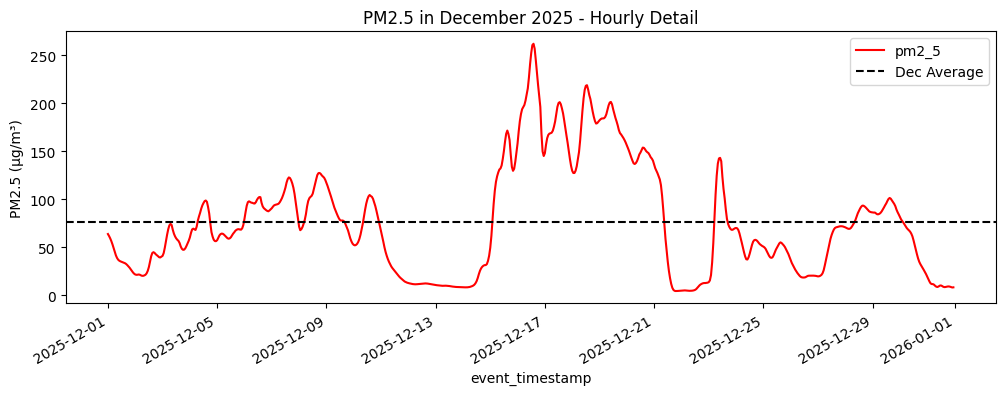

December PM2.5 stats:
  Max: 262.0 µg/m³
  Mean: 76.9 µg/m³
  % days > WHO: 83.9%


In [ ]:
december_all = df[df['month'] == 12]
december_all.set_index('event_timestamp')['pm2_5'].plot(figsize=(14,4), color='red')
plt.title(f'PM2.5 in ALL Decembers ({december_all["event_timestamp"].dt.year.unique()})')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=december_all['pm2_5'].mean(), color='black', linestyle='--', label='Dec Average')
plt.legend()
plt.show()

print(f"December PM2.5 stats:")
print(f"  Max: {december_all['pm2_5'].max():.1f} µg/m³")
print(f"  Mean: {december_all['pm2_5'].mean():.1f} µg/m³")
print(f"  % days > WHO: {(december_all['pm25_exceeds_who'].mean()*100):.1f}%")

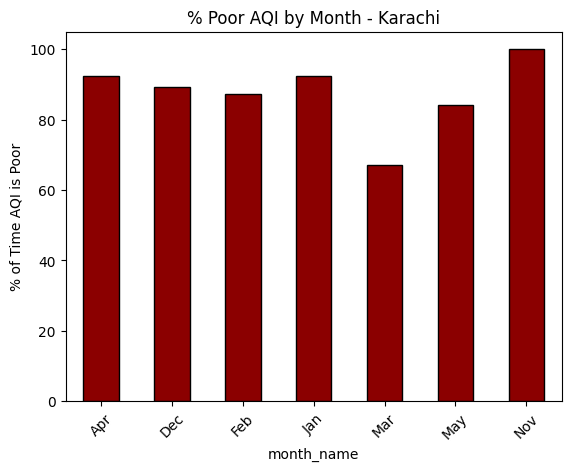

In [11]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['month_name'] = df['month'].map(month_names)

monthly_aqi = df.groupby('month_name')['aqi_is_poor'].mean() * 100
monthly_aqi.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% Poor AQI by Month - Karachi')
plt.ylabel('% of Time AQI is Poor')
plt.xticks(rotation=45)
plt.show()